In [1]:
%matplotlib widget 
# Uncomment for interactive plots when running the notebook!

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Ellipse

import mpl_toolkits.mplot3d.art3d as art3d

import import_ipynb

import PyPO
from PyPO.System import System
from PyPO.Enums import Projections, Units, Objects, FieldComponents, CurrentComponents

/home/pgrimes/miniforge3/envs/pypo/lib/python3.14/site-packages/PyPO/System.py:2019: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  labels = [f'{comp.name} $\phi=${phi:.0f}°', f'{comp.name} $\phi=${phi+90:.0f}°']
/home/pgrimes/miniforge3/envs/pypo/lib/python3.14/site-packages/PyPO/System.py:2019: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  labels = [f'{comp.name} $\phi=${phi:.0f}°', f'{comp.name} $\phi=${phi+90:.0f}°']
/home/pgrimes/miniforge3/envs/pypo/lib/python3.14/site-packages/PyPO/System.py:2029: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  labels = [f'{comp_cross.name} $\phi=${phi_cross:.0f}°', f'{comp_cross.name} $\phi=${phi_cross+90:.0f}°']
/home/pgrimes/miniforge3/envs/p

In [2]:
# This code allows us to display global variables within markdown output, by overriding the %%markdown magic
from IPython.display import Markdown
from IPython.core.magic import register_cell_magic

@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

# SMA Ray tracing
We set up and simulate the SMA primary, secondary and tertiary optics for ray tracing

We start by getting up the SMA antenna system

2026-03-17 17:05:52 - WARNING - System override set to True. 
Primary Focal Length (F_p) : 2.520 m
Primary Rim Height (h_p): 0.893 m
Angle of edge ray (alpha) :61.52543906847784°
Vertical distance from prime focus to secondary edge plane (z_sedge1): 0.094917 m
Distance from prime focus to secondary edge plane (r_sedge1): 0.094916667 m
Angle of edge ray from Cassegrain focus to secondary edge (thetae) 2.0462388063868757°
Distance from Cassegrain focus to secondary edge (r_sedge2) 4.901135272577161 m
Subreflector eccentricity (e_s): 1.0618612323260763

Subreflector conic constant (k): -1.1275492767170534
Subreflector distance to vertex (a_s) : 2.351025969621911 m
Subreflector distance to focus (c_s): 2.496463333333331 m
Subreflector distance between foci (2 c_s) : 4.992926666666662 m
Ratio between distance between foci and Primary focal length (2 c_s/F_p) : 1.981320105820104
Subreflector (b_s) : 0.8396463927398957 m

Subreflector radius of curvature on axis (R_s): 0.28240193053417684 m
S

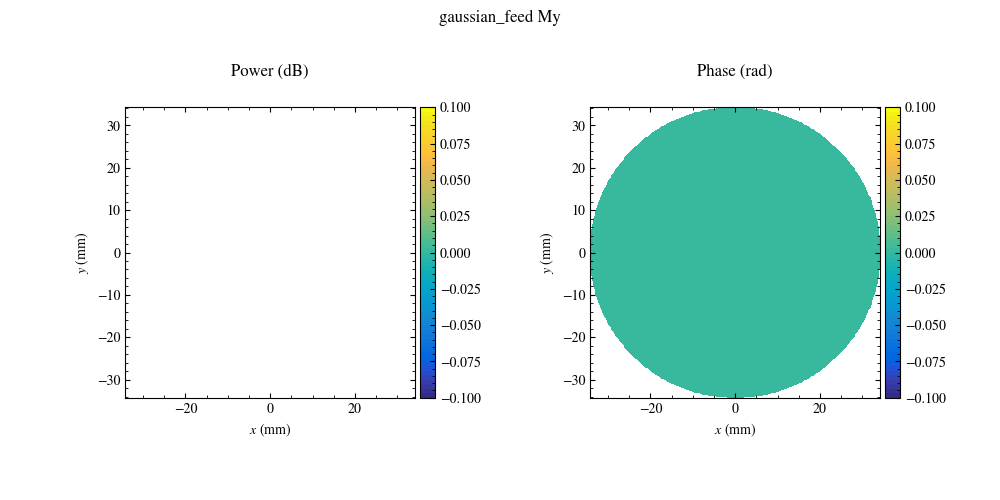

820.408910848911
Estimated Grid size : (341, 820)
Maximum Grid size   : (269, 1691)
2026-03-17 17:05:52 - INFO - Added hyperboloid secondary to system. 
2754.444791392808
Estimated Grid size : (1147, 2754)
Maximum Grid size   : (4615, 28999)
2026-03-17 17:05:52 - INFO - Added paraboloid primary to system. 
2026-03-17 17:05:52 - INFO - Added plane sec_plane to system. 
2026-03-17 17:05:52 - INFO - Translated element sec_plane by ('0.000e+00', '0.000e+00', '2.425e+03') millimeters. 
2026-03-17 17:05:52 - INFO - Added plane farfield_plane to system. 


In [3]:
# SMA antenna system
from sma_cassegrain_setup import s, F_p, h_p, D_p, D_s, lam

# Beam Waveguide

Next we define the beam waveguide

In [4]:
# Beam waveguide parameters, from Beam Waveguide Design Calculations:
from design.sma_beamwaveguide_design import z_vf, z_L1, z_M6, z_M5, z_M4, z_M3, z_pv, z_sr

# Gaussian beam waveguide parameters from Beam Waveguide Gaussian Beam Calculations
from design.sma_beamwaveguide_gaussian import outputBeamM4, inputBeamM4, outputBeamM5, inputBeamM5, inputBeamM2, virtualFeed
from design.sma_beamwaveguide_gaussian import M6 as inputBeamM6



M4M5_bendangle = 24.9

Radius of feed image: a_sr = 228.6 mm
Beam radius: w_sr = 147.1 mm
Magnification: m = 0.2057
Distance from virtual feed to M5 : L_1 = 2941.0 mm
Distance from M4 to secondary : L_4 = 4901.1 mm
Distance from intermediate image to M5 : L_2 = 964.9 mm
Distance from intermediate image to M4 : L_3 = 330.8 mm
z position of intermediate image : z_i = 3125.9 mm
beam radius of intermediate image : w_i = 9.9245 mm
focal length of M5 : f_M5 = 726.529 mm
focal length of M4 : f_M4 = 309.841 mm
radius of curvature of intermediate image : r_i = -333.721 mm
radius of curvature of secondary image : r_sr = 4898.157 mm
Distance from L1 to virtual image : L_6 = -780.0 mm
Virtual Feed waist properties: w0 = 15.288 mm, zc = 563.360 mm
Virtual Feed waist distance from L1: z = -0.182 m
Beam properties at L1: w = 16.065 mm, R = -1.927 m
Beam properties at M6: w = 45.501 mm, R = 1.780 m
Beam properties at M5: w = 55.844 mm, R = 2.140 m
M5 output beam properties at M5: w = 55.844 mm, R = -1.100 m
M5 output waist 

In [5]:
print(f"Distance from secondary edge to primary vertex: {(z_sr - z_pv)*Units.M:3f} mm")
print(f"Distance from secondary edge to primary focus: {(F_p - z_sr + z_pv)*Units.M:3f} mm")
print(f"Distance from Primary vertex to M3 : {(z_pv - z_M3)*Units.M:3f} mm")

Distance from secondary edge to primary vertex: 2425.000000 mm
Distance from secondary edge to primary focus: 95.000000 mm
Distance from Primary vertex to M3 : 2041.000000 mm


In [6]:
print("Beam properties at Secondary (z={:.3f} mm) : w = {:.3f} mm, R = {:.3f} m".format(outputBeamM4.z*Units.M, outputBeamM4.w*Units.M, outputBeamM4.R))
outputBeamM4.z = -22.182/Units.M.value[0]
print("Beam properties leaving M4 (z={:.3f} mm) : w = {:.3f} mm, R = {:.3f} m".format(outputBeamM4.z*Units.M, outputBeamM4.w*Units.M, outputBeamM4.R))
print("Beam properties entering M4 (z={:.3f} mm) : w = {:.3f} mm, R = {:.3f} m".format(inputBeamM4.z*Units.M, inputBeamM4.w*Units.M, inputBeamM4.R))


Beam properties at Secondary (z=4855.219 mm) : w = 147.101 mm, R = 4.898 m
Beam properties leaving M4 (z=-22.182 mm) : w = 13.771 mm, R = -9.395 m
Beam properties entering M4 (z=218.540 mm) : w = 13.824 mm, R = 0.332 m


In [7]:
def magnitude(vec):
    return np.sqrt(np.sum(vec**2))

## M3 Definition

In [8]:
M3_rim_b = 75.0
M3_rim_a = M3_rim_b / np.cos(np.deg2rad(45))
M3_rim_ecc = np.sqrt(1 - M3_rim_b**2 / M3_rim_a**2)


In [9]:
# Calculate size of grid required for M4

z = 1.09*np.pi*2*M3_rim_b/lam*np.sin(np.atan((M3_rim_b + D_s/2)*Units.MM / ((z_sr-z_M3)*Units.M))) + 10
print(z)

po1 = int(z/2.4)
po2 = int(z)

max_po1 = int(4*M3_rim_b/lam)
max_po2 = int(4*np.pi*M3_rim_b/lam)

print(f"Estimated Grid size : ({po1:d}, {po2:d})")
print(f"Maximum Grid size   : ({max_po1:d}, {max_po2:d})")

16.649936180842786
Estimated Grid size : (6, 16)
Maximum Grid size   : (230, 724)


In [10]:

flat_M3 = {
    "name"      : "flat_M3",
    "gmode"     : "uv",
    "lims_u"    : np.array([0, M3_rim_a]),
    "ecc_uv"    : M3_rim_ecc,
    "rot_uv"    : 90,
    "lims_v"    : np.array([0, 360]),
    "gridsize"  : np.array([26,16])
}

s.addPlane(flat_M3)
s.rotateGrids("flat_M3", np.array([45, 0, 0]))

M3_center = np.array([0, 0, (z_M3 - z_pv)*Units.M])
M3_position = M3_center
s.translateGrids("flat_M3", M3_center)

# Only for tolerancing
#s.rotateGrids("flat_M3", np.array([0, 0, 0]), pivot=M3_position)


2026-03-17 17:05:53 - INFO - Added plane flat_M3 to system. 
2026-03-17 17:05:53 - INFO - Rotated element flat_M3 by ('4.500e+01', '0.000e+00', '0.000e+00') degrees around ('0.000e+00', '0.000e+00', '0.000e+00'). 
2026-03-17 17:05:53 - INFO - Translated element flat_M3 by ('0.000e+00', '0.000e+00', '-2.041e+03') millimeters. 


## M4 Definition

In [11]:
# Ellipse where input ray is <45° or >135° from ellipse axis

M4_focus1 = np.array([0, 0, -outputBeamM4.R*Units.M])
M4_focus2 = np.array([inputBeamM4.R*Units.M*np.sin(np.deg2rad(M4M5_bendangle*2)), 0, inputBeamM4.R*Units.M*np.cos(np.deg2rad(M4M5_bendangle*2))])
M4_r1 = magnitude(M4_focus1)
M4_r2 = magnitude(M4_focus2)
M4_center = (M4_focus1 + M4_focus2)/2
M4_angle = np.atan2((M4_focus2 - M4_focus1)[0], (M4_focus2 - M4_focus1)[2])
M4_a = (M4_r1 + M4_r2)/2
M4_c = magnitude(M4_focus1 - M4_focus2)/2
M4_b = np.sqrt(M4_a**2 - M4_c**2)
M4_ecc = M4_c/M4_a
M4_v = np.acos((M4_a/M4_r1*(1 - M4_ecc**2) - 1) / M4_ecc)
M4_vprime = np.acos((1 - M4_a/M4_r2*(1 - M4_ecc**2)) / M4_ecc)
M4_rho = M4_r1*np.sin(M4_v)
M4_z = np.sqrt(M4_a**2*(1 - M4_rho**2/M4_b**2))

M4_rim_radius = 75.0

M4_rim_b = np.abs(M4_rim_radius*np.cos(M4_angle))
M4_rim_a = M4_rim_radius
M4_rim_ecc = np.sqrt(1 - M4_rim_b**2 / M4_rim_a**2)

print(f"Ellipsoid focus 1: {M4_focus1}")
print(f"Ellipsoid r : {M4_r1:.3f}")
print(f"Ellipsoid focus 2: {M4_focus2}")
print(f"Ellipsoid r' : {M4_r2:.3f}")

print(f"Ellipsoid center : {M4_center}")
print(f"Ellipsoid a : {M4_a:.3f}")
print(f"Ellipsoid c : {M4_c:.3f}")
print(f"Ellipsoid b : {M4_b:.3f}")
print(f"Ellipsoid e : {M4_ecc:.4f}")
print(f"Bend angle: {-M4M5_bendangle:.3f}°")
print(f"angle of ellipse axis to input ray: {np.rad2deg(M4_angle):3f}°")
print(f"angle of input ray: {np.rad2deg(M4_v):.3f}°")
print(f"angle of output ray: {np.rad2deg(M4_vprime):.3f}°")
print(f"rho of vertex: {M4_rho} mm")
print(f"z of vertex: {M4_z} mm")
print(f"Long axis of rim: {M4_rim_a:.3f}")
print(f"Short axis of rim: {M4_rim_b:.3f}")
print(f"Eccentricity of rim: {M4_rim_ecc:.3f}")


Ellipsoid focus 1: [   0.            0.         9395.42652355]
Ellipsoid r : 9395.427
Ellipsoid focus 2: [253.78668607   0.         214.4663777 ]
Ellipsoid r' : 332.270
Ellipsoid center : [ 126.89334303    0.         4804.94645062]
Ellipsoid a : 4863.848
Ellipsoid c : 4592.234
Ellipsoid b : 1602.627
Ellipsoid e : 0.9442
Bend angle: -24.900°
angle of ellipse axis to input ray: 178.416592°
angle of input ray: 178.417°
angle of output ray: 128.617°
rho of vertex: 259.61594961400925 mm
z of vertex: 4799.605387172472 mm
Long axis of rim: 75.000
Short axis of rim: 74.971
Eccentricity of rim: 0.028


In [12]:
# Calculate size of grid required for M4

z = 1.09*np.pi*2*M4_rim_a/lam*np.sin(np.atan((M4_rim_a + M3_rim_a)*Units.MM / ((z_M3-z_M4)*Units.M))) + 10
print(z)

po1 = int(z/2.4)
po2 = int(z)

max_po1 = int(4*M4_rim_a/lam)
max_po2 = int(4*np.pi*M4_rim_a/lam)

print(f"Estimated Grid size : ({po1:d}, {po2:d})")
print(f"Maximum Grid size   : ({max_po1:d}, {max_po2:d})")

161.8063594823821
Estimated Grid size : (67, 161)
Maximum Grid size   : (230, 724)


In [13]:

quadric_M4 = {
    "name"      : "quadric_M4",
    "pmode"     : "focus",
    "gmode"     : "uv",
    "flip"      : True,
    "focus_1"   : M4_focus2,
    "focus_2"   : M4_focus1,
    "vertex"    : np.array([0, 0, 0]),
    "ecc"       : M4_c/M4_a,
    "orient"    : "z",
    "lims_u"    : np.array([0, M4_rim_a]),
    "ecc_uv"    : M4_rim_ecc,
    "rot_uv"    : 0,
    "lims_v"    : np.array([0, 360]),
    "gcenter"   : np.array([M4_rho, 0]),
    "gridsize"  : np.array([32, 69])
}
s.addEllipse(quadric_M4)
# Now the reflector is centered at the origin


2026-03-17 17:05:53 - INFO - Added ellipsoid quadric_M4 to system. 


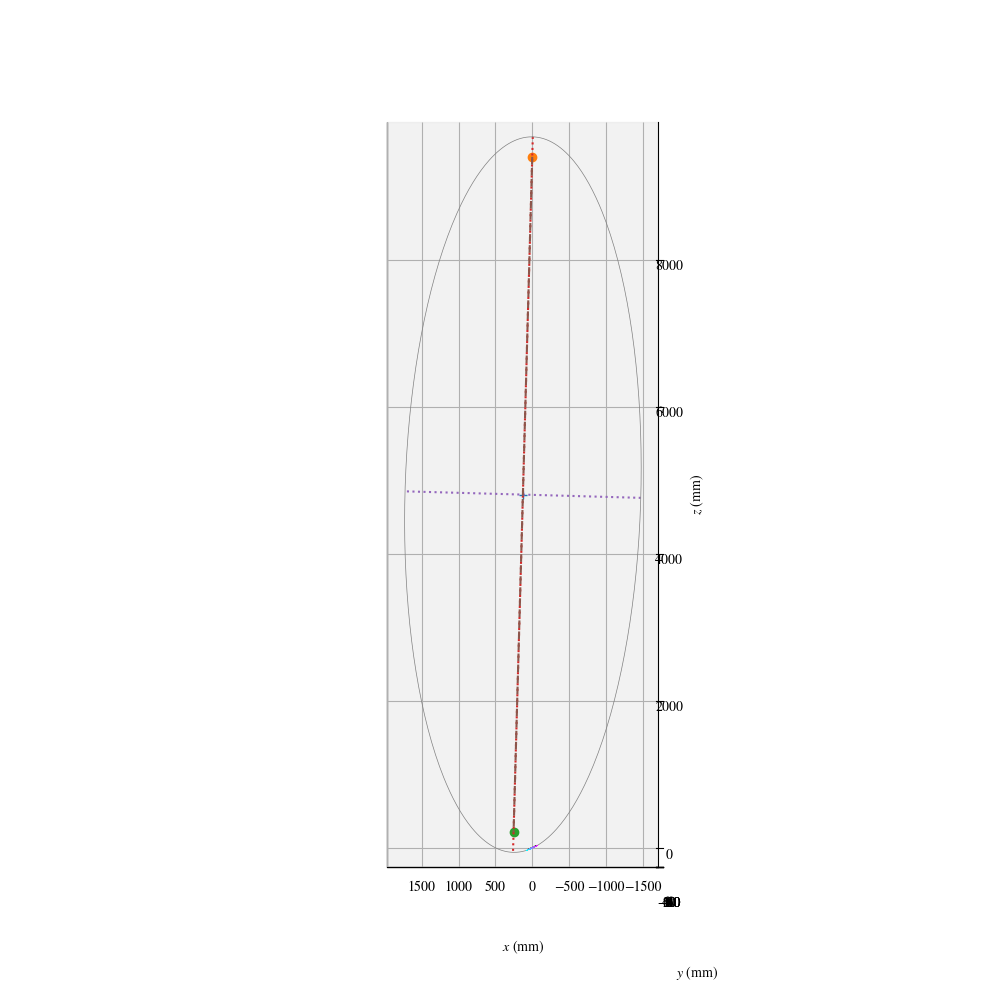

In [14]:
fig, ax = s.plotSystem(select=["quadric_M4"], norm=True, ret=True)
ax.set_proj_type('ortho')
ax.view_init(elev=0, azim=90, roll=0)

ax.plot(*M4_center, '+', label='Ellipse Center')
ax.plot(*M4_focus1 , 'o', label='Focus 1')
ax.plot(*M4_focus2, 'o', label='Focus 2')

t = np.linspace(-1.0, 1.0, 101)

M4_axis_x = t*M4_a*np.sin(M4_angle) + M4_center[0]
M4_axis_y = np.zeros_like(t)
M4_axis_z = t*M4_a*np.cos(M4_angle) + M4_center[2]

ax.plot(M4_axis_x, M4_axis_y, M4_axis_z, ":")

M4_minoraxis_x = -t*M4_b*np.cos(M4_angle) + M4_center[0]
M4_minoraxis_y = np.zeros_like(t)
M4_minoraxis_z = t*M4_b*np.sin(M4_angle) + M4_center[2]

ax.plot(M4_minoraxis_x, M4_minoraxis_y, M4_minoraxis_z, ":")

M4_2faxis_x = t*M4_c*np.sin(M4_angle) + M4_center[0]
M4_2faxis_y = np.zeros_like(t)
M4_2faxis_z = t*M4_c*np.cos(M4_angle) + M4_center[2]

ax.plot(M4_2faxis_x, M4_2faxis_y, M4_2faxis_z, "--")

ellipse = Ellipse(
    xy=(M4_center[0], M4_center[2]),
    width=M4_b*2,
    height=M4_a*2,
    angle=-np.rad2deg(M4_angle),
    facecolor="none",
    edgecolor="b"
)
verts = ellipse.get_verts()

ax.plot(verts[:,0], np.zeros_like(verts[:,0]), verts[:,1], 'gray', lw=0.5)

ax.set_aspect('equal', adjustable='box')

In [15]:

# Translate to correct distance from Primary
s.translateGrids("quadric_M4", np.array([0, 0, (z_M4 - z_pv)*Units.M]))

# Fold about M3
s.rotateGrids("quadric_M4", np.array([-90, 0, 0]), pivot=M3_position)


2026-03-17 17:05:53 - INFO - Translated element quadric_M4 by ('0.000e+00', '0.000e+00', '-2.476e+03') millimeters. 
2026-03-17 17:05:53 - INFO - Rotated element quadric_M4 by ('-9.000e+01', '0.000e+00', '0.000e+00') degrees around ('0.000e+00', '0.000e+00', '-2.041e+03'). 


In [16]:
M4_grid = s.generateGrids("quadric_M4")
M4_position = np.array([M4_grid.x[0,0], M4_grid.y[0,0], M4_grid.z[0,0]])

In [17]:
M4M3_d = np.sqrt((M4_position - M3_position)[0]**2 + (M4_position - M3_position)[1]**2 + (M4_position - M3_position)[2]**2)
print(f"Nominal M3-M4 distance: {(z_M3-z_M4)*1e3:.2f} mm")
print(f"Actual M3-M4 distance: {M4M3_d:.2f} mm")

# Only for tolerancing
#s.rotateGrids("quadric_M4", np.array([0, 0, 0.1]), pivot=M4_position)

Nominal M3-M4 distance: 435.10 mm
Actual M3-M4 distance: 435.10 mm


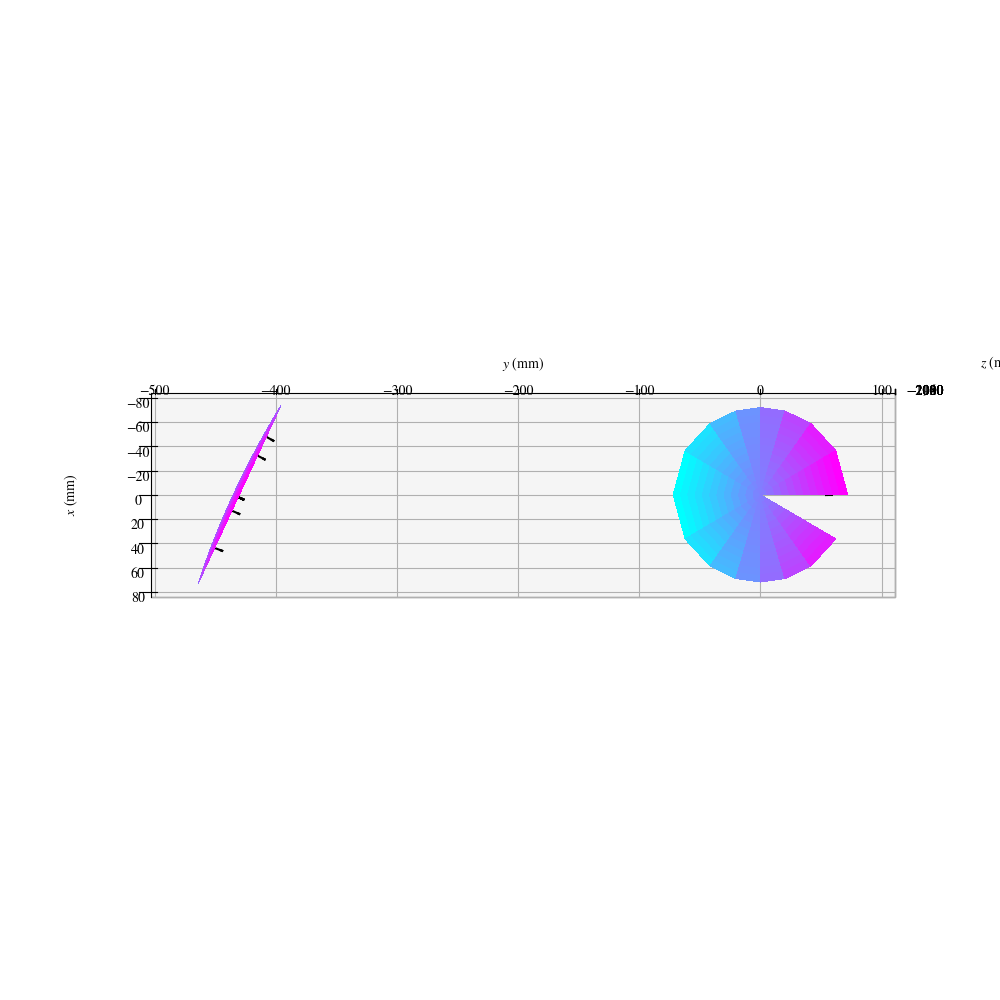

In [18]:
fig, ax = s.plotSystem(select=["quadric_M4", "flat_M3"], norm=True, ret=True)
ax.set_proj_type('ortho')
ax.view_init(elev=90, azim=0, roll=0)

## M5 Definition

In [19]:
print("Beam properties leaving M5 (z={:.3f} mm) : w = {:.3f} mm, R = {:.3f} m".format(outputBeamM5.z*Units.M, outputBeamM5.w*Units.M, outputBeamM5.R))
print("Beam properties entering M5 (z={:.3f} mm) : w = {:.3f} mm, R = {:.3f} m".format(inputBeamM5.z*Units.M, inputBeamM5.w*Units.M, inputBeamM5.R))


Beam properties leaving M5 (z=-1077.100 mm) : w = 55.844 mm, R = -1.100 m
Beam properties entering M5 (z=1979.169 mm) : w = 55.844 mm, R = 2.140 m


In [20]:
# Ellipse where input ray is >45° and <135° from ellipse axis

M5_focus1 = np.array([0, 0, -outputBeamM5.R*Units.M])
M5_focus2 = np.array([-inputBeamM5.R*Units.M*np.sin(np.deg2rad(M4M5_bendangle*2)), 0, inputBeamM5.R*Units.M*np.cos(np.deg2rad(M4M5_bendangle*2))])
M5_r1 = magnitude(M5_focus1)
M5_r2 = magnitude(M5_focus2)
M5_center = (M5_focus1 + M5_focus2)/2
M5_angle = np.atan2((M5_focus2 - M5_focus1)[0], (M5_focus2 - M5_focus1)[2])
M5_a = (M5_r1 + M5_r2)/2
M5_c = magnitude(M5_focus1 - M5_focus2)/2
M5_b = np.sqrt(M5_a**2 - M5_c**2)
M5_ecc = M5_c/M5_a
M5_v = np.acos((M5_a/M5_r1*(1 - M5_ecc**2) - 1) / M5_ecc)
M5_vprime = np.acos((1 - M5_a/M5_r2*(1 - M5_ecc**2)) / M5_ecc)
M5_rho = M5_r1*np.sin(M5_v)
M5_z = np.sqrt(M5_a**2*(1 - M5_rho**2/M5_b**2))

M5_rim_radius = 150.0

M5_rim_b = M5_rim_radius*np.sin(M5_angle)
M5_rim_a = M5_rim_radius
M5_rim_ecc = np.sqrt(1 - M5_rim_b**2 / M5_rim_a**2)

print(f"Ellipsoid focus 1: {M5_focus1}")
print(f"Ellipsoid r : {M5_r1:.3f}")
print(f"Ellipsoid focus 2: {M5_focus2}")
print(f"Ellipsoid r' : {M5_r2:.3f}")

print(f"Ellipsoid center : {M5_center}")
print(f"Ellipsoid a : {M5_a:.3f}")
print(f"Ellipsoid c : {M5_c:.3f}")
print(f"Ellipsoid b : {M5_b:.3f}")
print(f"Ellipsoid e : {M5_ecc:.4f}")
print(f"Bend angle: {-M4M5_bendangle:.3f}°")
print(f"angle of ellipse axis to input ray: {np.rad2deg(M5_angle):3f}°")
print(f"angle of input ray: {np.rad2deg(M5_v):.3f}°")
print(f"angle of output ray: {np.rad2deg(M5_vprime):.3f}°")
print(f"rho of vertex: {M5_rho} mm")
print(f"z of vertex: {M5_z} mm")
print(f"Long axis of rim: {M5_rim_a:.3f}")
print(f"Short axis of rim: {M5_rim_b:.3f}")
print(f"Eccentricity of rim: {M5_rim_ecc:.3f}")


Ellipsoid focus 1: [   0.           0.        1100.1750097]
Ellipsoid r : 1100.175
Ellipsoid focus 2: [-1634.16212905     0.          1380.97406852]
Ellipsoid r' : 2139.527
Ellipsoid center : [-817.08106453    0.         1240.57453911]
Ellipsoid a : 1619.851
Ellipsoid c : 829.056
Ellipsoid b : 1391.612
Ellipsoid e : 0.5118
Bend angle: -24.900°
angle of ellipse axis to input ray: -80.250046°
angle of input ray: 80.250°
angle of output ray: 30.450°
rho of vertex: 1084.2842965026034 mm
z of vertex: 1015.3690055612302 mm
Long axis of rim: 150.000
Short axis of rim: -147.833
Eccentricity of rim: 0.169


In [21]:
# Calculate size of grid required for M5

z = 1.09*np.pi*2*M5_rim_a/lam*np.sin(np.atan((M5_rim_a + M4_rim_a)*Units.MM / ((z_M4-z_M5)*Units.M))) + 10
print(z)

po1 = int(z/2.4)
po2 = int(z)

max_po1 = int(4*M5_rim_a/lam)
max_po2 = int(4*np.pi*M5_rim_a/lam)

print(f"Estimated Grid size : ({po1:d}, {po2:d})")
print(f"Maximum Grid size   : ({max_po1:d}, {max_po2:d})")

145.20744767991863
Estimated Grid size : (60, 145)
Maximum Grid size   : (461, 1449)


In [22]:


quadric_M5 = {
    "name"      : "quadric_M5",
    "pmode"     : "focus",
    "gmode"     : "uv",
    "flip"      : True,
    "focus_1"   : M5_focus2,
    "focus_2"   : M5_focus1,
    "vertex"    : np.array([0, 0, 0]),
    "ecc"       : M5_c/M5_a,
    "orient"    : "x",
    "lims_u"    : np.array([0, M5_rim_a]),
    "ecc_uv"    : M5_rim_ecc,
    "rot_uv"    : 0,
    "lims_v"    : np.array([0, 360]),
    "gcenter"   : np.array([-M5_z, 0]),
    "gridsize"  : np.array([23, 59])
}
s.addEllipse(quadric_M5)
#s.rotateGrids("quadric_M5", np.array([180, 0, 0]), pivot=M5_center)
#s.translateGrids("quadric_M5", np.array((-M5_center[0]*2, 0, 0)))
# Now the reflector is centered at the origin


2026-03-17 17:05:54 - INFO - Added ellipsoid quadric_M5 to system. 


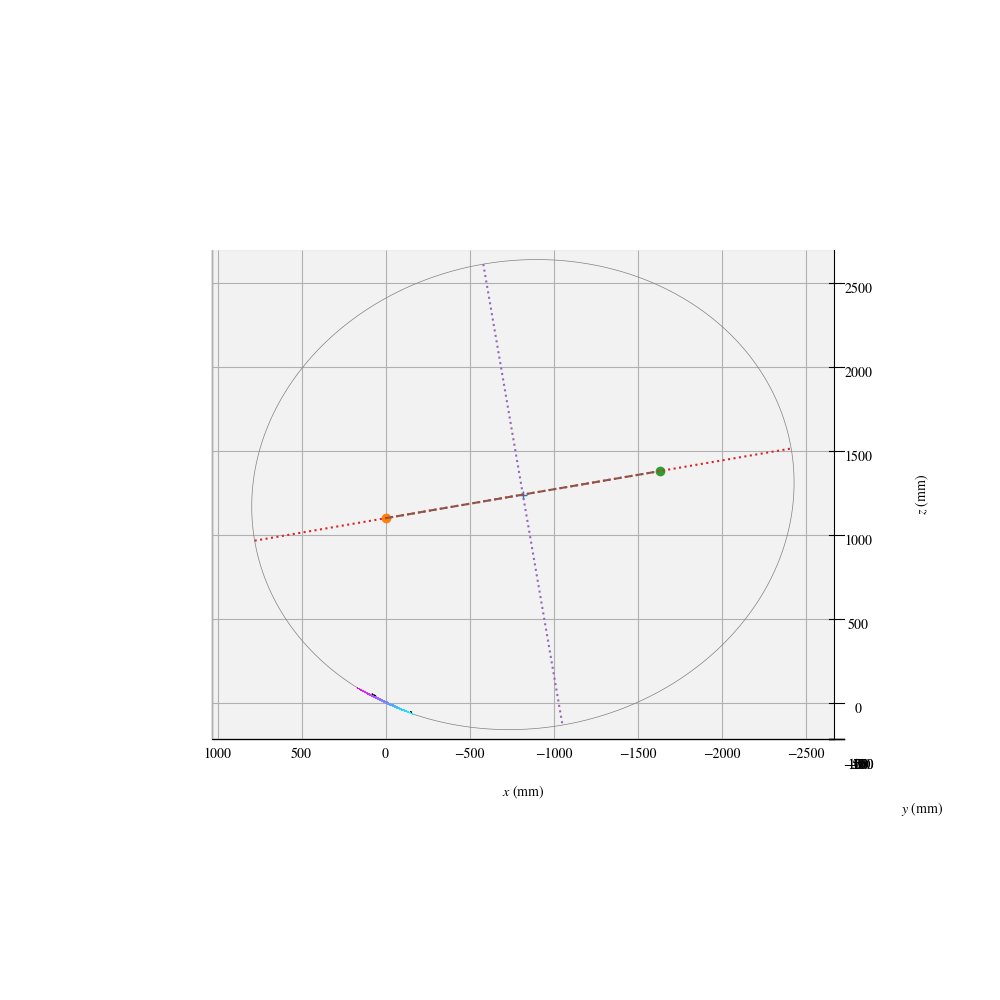

In [23]:
fig, ax = s.plotSystem(select=["quadric_M5"], norm=True, ret=True)
ax.set_proj_type('ortho')
ax.view_init(elev=0, azim=90, roll=0)


ax.plot(*M5_center, '+', label='Ellipse Center')
ax.plot(*M5_focus1 , 'o', label='Focus 1')
ax.plot(*M5_focus2, 'o', label='Focus 2')

t = np.linspace(-1.0, 1.0, 101)

M5_axis_x = t*M5_a*np.sin(M5_angle) + M5_center[0]
M5_axis_y = np.zeros_like(t)
M5_axis_z = t*M5_a*np.cos(M5_angle) + M5_center[2]

ax.plot(M5_axis_x, M5_axis_y, M5_axis_z, ":")

M5_minoraxis_x = -t*M5_b*np.cos(M5_angle) + M5_center[0]
M5_minoraxis_y = np.zeros_like(t)
M5_minoraxis_z = t*M5_b*np.sin(M5_angle) + M5_center[2]

ax.plot(M5_minoraxis_x, M5_minoraxis_y, M5_minoraxis_z, ":")

M5_2faxis_x = t*M5_c*np.sin(M5_angle) + M5_center[0]
M5_2faxis_y = np.zeros_like(t)
M5_2faxis_z = t*M5_c*np.cos(M5_angle) + M5_center[2]

ax.plot(M5_2faxis_x, M5_2faxis_y, M5_2faxis_z, "--")

ellipse = Ellipse(
    xy=(M5_center[0], M5_center[2]),
    width=M5_b*2,
    height=M5_a*2,
    angle=-np.rad2deg(M5_angle),
    facecolor="none",
    edgecolor="b"
)
verts = ellipse.get_verts()

ax.plot(verts[:,0], np.zeros_like(verts[:,0]), verts[:,1], 'gray', lw=0.5)

ax.set_aspect('equal', adjustable='box')

In [24]:

# Translate to correct distance from Primary
s.translateGrids("quadric_M5", np.array([0, 0, (z_M5 - z_pv)*Units.M]))

# Rotate around the center of M3
s.rotateGrids("quadric_M5", np.array([-90, 0, 0]), pivot=M3_center)

# Rotate around the center of M4
s.rotateGrids("quadric_M5", np.array([0, 0, 180-M4M5_bendangle*2]), pivot=M4_position)


2026-03-17 17:05:54 - INFO - Translated element quadric_M5 by ('0.000e+00', '0.000e+00', '-3.772e+03') millimeters. 
2026-03-17 17:05:54 - INFO - Rotated element quadric_M5 by ('-9.000e+01', '0.000e+00', '0.000e+00') degrees around ('0.000e+00', '0.000e+00', '-2.041e+03'). 
2026-03-17 17:05:54 - INFO - Rotated element quadric_M5 by ('0.000e+00', '0.000e+00', '1.302e+02') degrees around ('1.192e-11', '-4.351e+02', '-2.041e+03'). 


In [25]:
M5_grid = s.generateGrids("quadric_M5")
M5_position = np.array([M5_grid.x[0,0], M5_grid.y[0,0], M5_grid.z[0,0]])

# Only for tolerancing
#s.rotateGrids("quadric_M5", np.array([0, 0, 0.1]), pivot=M5_position)

In [26]:
M5M4_d = np.sqrt((M5_position - M4_position)[0]**2 + (M5_position - M4_position)[1]**2 + (M5_position - M4_position)[2]**2)
print(f"Nominal pv-M5 distance: {(z_M5 - z_pv)*Units.M} mm")
print(f"Nominal M4-M5 distance: {(z_M4-z_M5)*1e3:.2f} mm")
print(f"Actual M4-M5 distance: {M5M4_d:.2f} mm")

Nominal pv-M5 distance: -3771.74 mm
Nominal M4-M5 distance: 1295.64 mm
Actual M4-M5 distance: 1295.64 mm


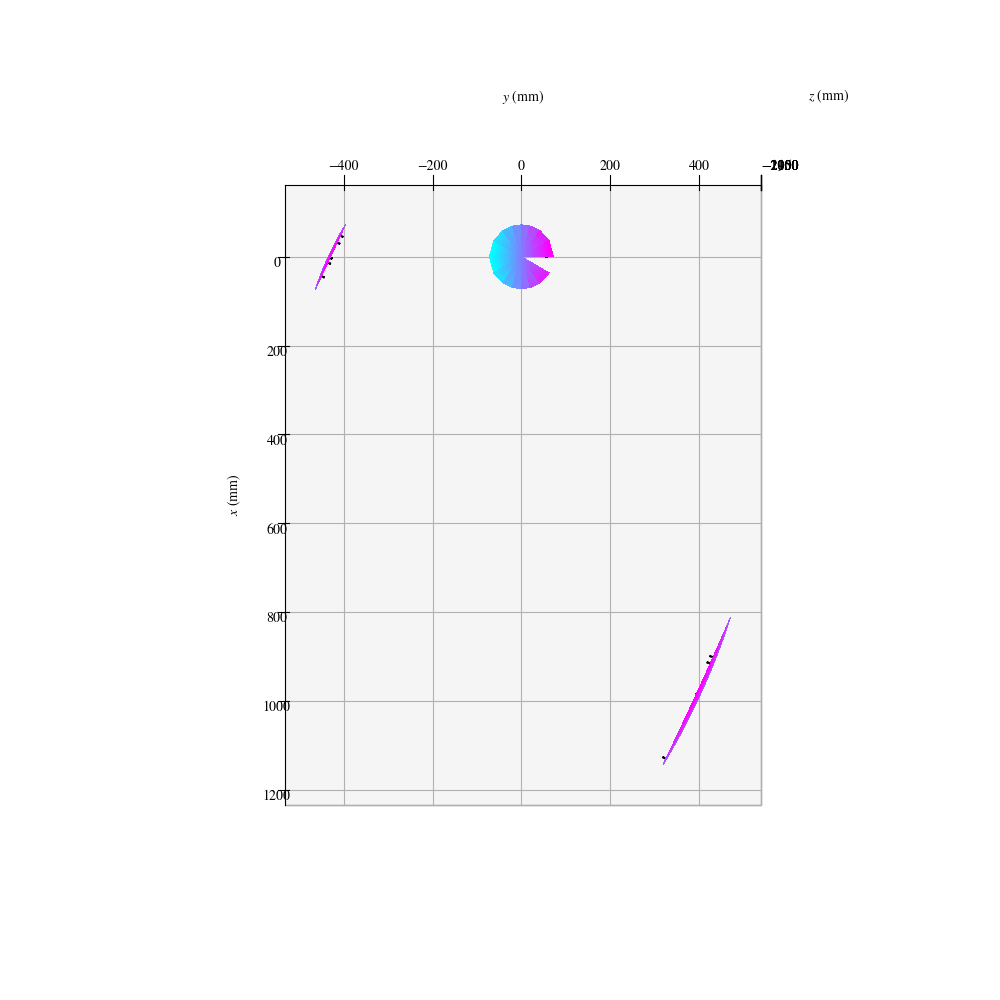

In [27]:
fig, ax = s.plotSystem(select=["flat_M3", "quadric_M4", "quadric_M5"], norm=True, ret=True)
ax.set_proj_type('ortho')
ax.view_init(elev=90, azim=0, roll=0)

## M6 Definition

We define M6, and then define the virtual feed Gaussian beam on it directly.  This provides an exact calculation of the currents on the M6 grid, without having to carry out PO propagation from the virtual feed to M6.

In [28]:
M6_rim_b = 150.0
M6_rim_a = M6_rim_b / np.cos(np.deg2rad(45))
M6_rim_ecc = np.sqrt(1 - M6_rim_b**2 / M6_rim_a**2)


In [29]:
# Calculate size of grid required for M6

z = 1.09*np.pi*2*M6_rim_b/lam*np.sin(np.atan((M6_rim_b + M5_rim_a)*Units.MM / ((z_M5-z_M6)*Units.M))) + 10
print(z)

po1 = int(z/2.4)
po2 = int(z)

max_po1 = int(4*M6_rim_b/lam)
max_po2 = int(4*np.pi*M6_rim_b/lam)

print(f"Estimated Grid size : ({po1:d}, {po2:d})")
print(f"Maximum Grid size   : ({max_po1:d}, {max_po2:d})")

484.1388297187058
Estimated Grid size : (201, 484)
Maximum Grid size   : (461, 1449)


### Virtual Feed Definition

In [30]:
print(f"Virtual Feed distance from beam waist: {virtualFeed.z*Units.M} mm")

z_M6vf = z_M6 - z_vf

print(f"Virtual Feed distance from M6: {z_M6vf*Units.M} mm")

z_M6waist = z_M6vf + virtualFeed.z

print(f"Beam waist distance from M6: {z_M6waist*Units.M} mm")


Virtual Feed distance from beam waist: -961.8306251331735 mm
Virtual Feed distance from M6: 2541.0000000000005 mm
Beam waist distance from M6: 1579.1693748668267 mm


In [31]:
# Calculate size of grid required for the virtual feed
r_feed = 2.5*virtualFeed.w*Units.M

z = 1.09*np.pi*2*2.5*r_feed/lam*np.sin(np.atan(M6_rim_b*Units.MM/2 / ((z_M6-z_vf)*Units.M))) + 10
print(z)

po1 = int(z/2.4)
po2 = int(z)

max_po1 = int(4*r_feed/lam)
max_po2 = int(4*np.pi*r_feed/lam)

print(f"Estimated Grid size : ({po1:d}, {po2:d})")
print(f"Maximum Grid size   : ({max_po1:d}, {max_po2:d})")

39.385691462950916
Estimated Grid size : (16, 39)
Maximum Grid size   : (232, 731)


In [ ]:
# Add M6 and rotate it by 45°
flat_M6 = {
    "name"      : "flat_M6",
    "gmode"     : "uv",
    "lims_u"    : np.array([0, M6_rim_a]),
    "ecc_uv"    : M6_rim_ecc,
    "rot_uv"    : 90,
    "lims_v"    : np.array([0, 360]),
    "gridsize"  : np.array([232, 720])*2
}

s.addPlane(flat_M6)

s.rotateGrids("flat_M6", np.array([45.0, 0, 0]))

s.translateGrids("flat_M6", np.array([0,0, M6_rim_a+1]))

2026-03-18 14:19:16 - INFO - Added plane flat_M6 to system. 
2026-03-18 14:19:17 - INFO - Rotated element flat_M6 by ('4.500e+01', '0.000e+00', '0.000e+00') degrees around ('0.000e+00', '0.000e+00', '0.000e+00'). 
2026-03-18 14:19:17 - INFO - Translated element flat_M6 by ('0.000e+00', '0.000e+00', '2.131e+02') millimeters. 


In [33]:
# Create the Gaussian Beam on M6
feed = {
        "name"      : "feed",
        "lam"       : virtualFeed.wavelength*Units.M,
        "w0"        : virtualFeed.w0*Units.M,
        "z"         : z_M6waist*Units.M - M6_rim_a+1,
        "mode"      : "pec"
        }

s.createGaussianBeam(feed, 'flat_M6')

s.translateGrids("flat_M6", np.array([0,0, -M6_rim_a+1]))

{'name': 'feed', 'lam': 1.3034454695652173, 'w0': np.float64(15.288488674967324), 'z': np.float64(1368.0373405108626), 'mode': 2, 'n': 1.0, 'power': 12.566370614359172}
2026-03-17 17:05:55 - INFO - Translated element flat_M6 by ('0.000e+00', '0.000e+00', '-2.111e+02') millimeters. 


In [34]:
feed

{'name': 'feed',
 'lam': 1.3034454695652173,
 'w0': np.float64(15.288488674967324),
 'z': np.float64(1368.0373405108626),
 'mode': 'pec'}

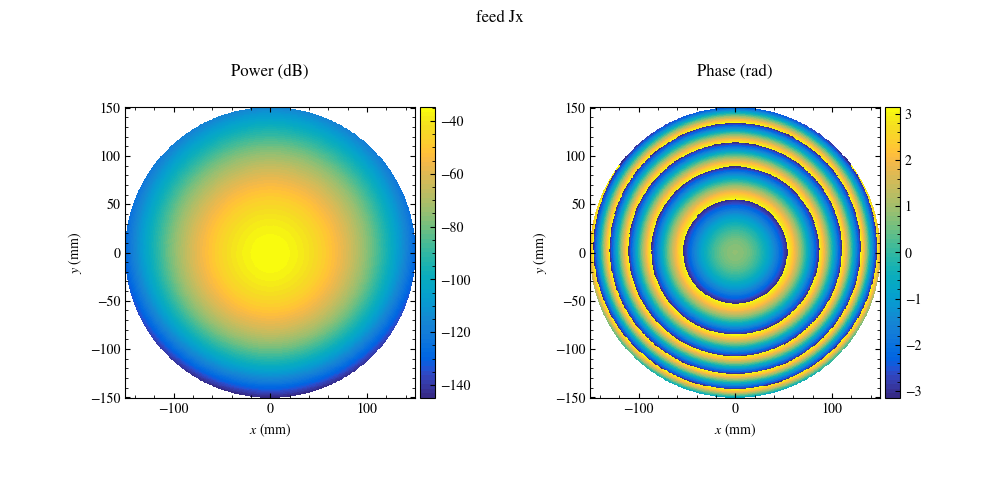

In [35]:
s.plotBeam2D("feed", CurrentComponents.Jx, correct_phase=[0,-1,0], norm=False, contour="feed", contour_comp=CurrentComponents.Jx, levels=[-12.7, -10, 20*np.log10(np.exp(-1))])

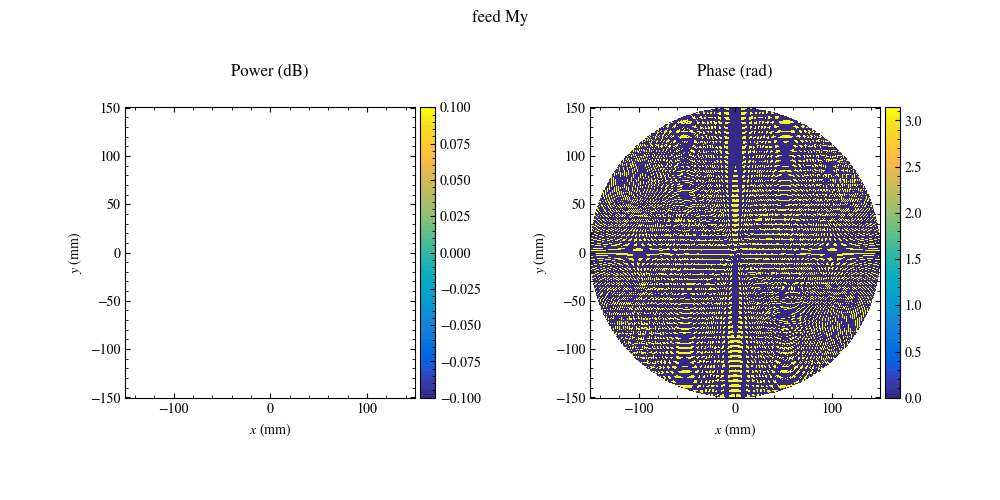

In [36]:
s.plotBeam2D("feed", CurrentComponents.My, correct_phase=[0,-1,0], norm=False, contour="feed", contour_comp=CurrentComponents.My, levels=[-12.7, -10, 20*np.log10(np.exp(-1))])

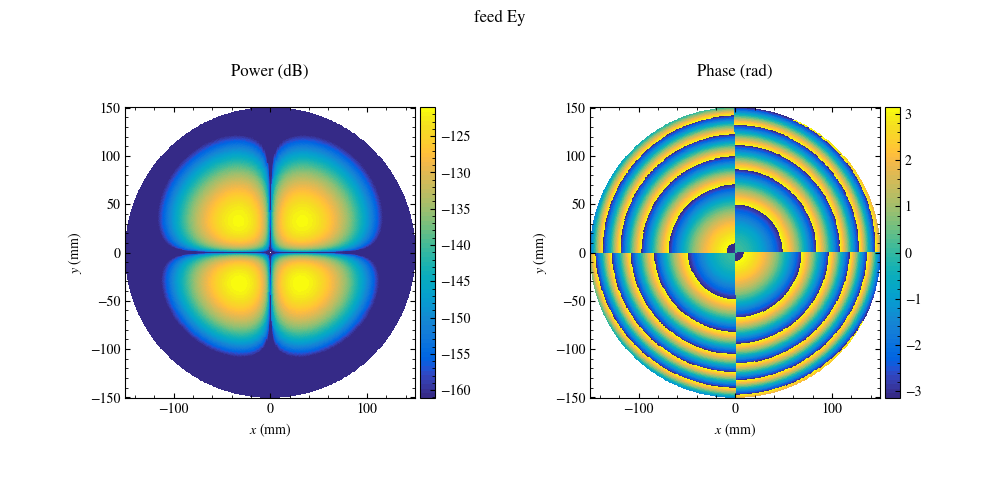

In [36]:
s.plotBeam2D("feed", FieldComponents.Ey, correct_phase=[0,-1,0], contour="feed", norm=False, vmin=-40, contour_comp=FieldComponents.Ey, levels=[-12.7, -10, 20*np.log10(np.exp(-1))])

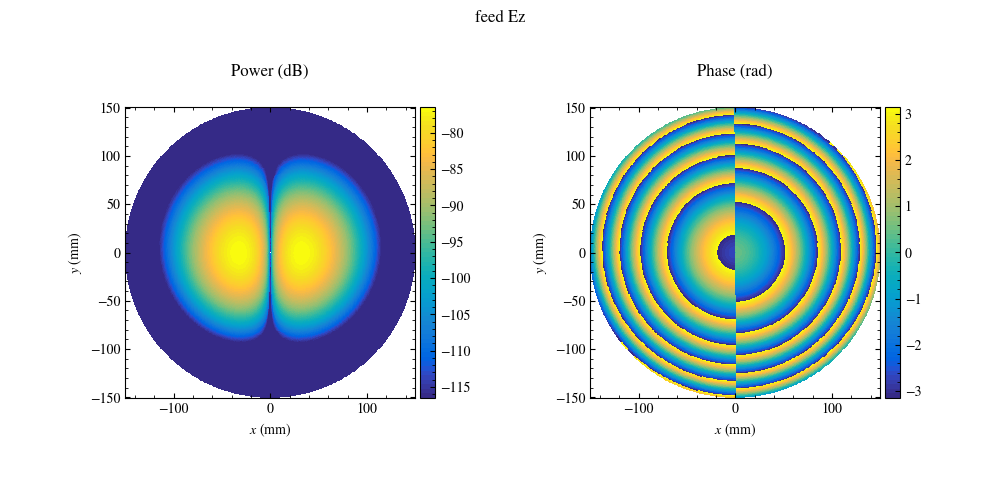

In [37]:
s.plotBeam2D("feed", FieldComponents.Ez, correct_phase=[0,-1,0], contour="feed", norm=False, vmin=-40, contour_comp=FieldComponents.Ez, levels=[-12.7, -10, 20*np.log10(np.exp(-1))])

In [38]:
# Now translate M6 and its fields into the correct position

# Offset M6 by distance from Primary vertex
s.translateGrids("flat_M6", np.array([0, 0, (z_M6 - z_pv)*Units.M]))

# Fold about M3
s.rotateGrids("flat_M6", np.array([-90, 180, 0]), pivot=M3_position)

# Fold about M4
s.rotateGrids("flat_M6", np.array([0,0, 180-M4M5_bendangle*2]), pivot=M4_position)

# Fold about M5
s.rotateGrids("flat_M6", np.array([0,0, 180+M4M5_bendangle*2]), pivot=M5_position)

2026-03-17 17:04:29 - INFO - Translated element flat_M6 by ('0.000e+00', '0.000e+00', '-4.172e+03') millimeters. 
2026-03-17 17:04:30 - INFO - Rotated element flat_M6 by ('-9.000e+01', '1.800e+02', '0.000e+00') degrees around ('0.000e+00', '0.000e+00', '-2.041e+03'). 
2026-03-17 17:04:30 - INFO - Rotated element flat_M6 by ('0.000e+00', '0.000e+00', '1.302e+02') degrees around ('1.192e-11', '-4.351e+02', '-2.041e+03'). 
2026-03-17 17:04:31 - INFO - Rotated element flat_M6 by ('0.000e+00', '0.000e+00', '2.298e+02') degrees around ('9.896e+02', '4.012e+02', '-2.041e+03'). 


In [39]:
M6_grid = s.generateGrids("flat_M6")
M6_position = np.array([M6_grid.x[0,0], M6_grid.y[0,0], M6_grid.z[0,0]])

In [40]:
M6M5_d = np.sqrt((M6_position - M5_position)[0]**2 + (M6_position - M5_position)[1]**2 + (M6_position - M5_position)[2]**2)
print(f"Nominal M5-M6 distance: {(z_M5-z_M6)*1e3:.2f} mm")
print(f"Actual M5-M6 distance: {M6M5_d:.2f} mm")

Nominal M5-M6 distance: 400.00 mm
Actual M5-M6 distance: 398.00 mm


In [41]:
# fig, ax = s.plotSystem(select=["secondary", "flat_M3", "quadric_M4", "quadric_M5", "flat_M6"], norm=True, ret=True)
# ax.set_proj_type('ortho')
# ax.view_init(elev=90, azim=0, roll=0)

## Virtual Feed Definition

In [42]:
# print(f"Virtual Feed distance from beam waist: {virtualFeed.z*Units.M} mm")

In [43]:
# # Calculate size of grid required for the virtual feed
# r_feed = 2.5*virtualFeed.w*Units.M

# z = 1.09*np.pi*2*2.5*r_feed/lam*np.sin(np.atan(M6_rim_b*Units.MM/2 / ((z_M6-z_vf)*Units.M))) + 10
# print(z)

# po1 = int(z/2.4)
# po2 = int(z)

# max_po1 = int(4*r_feed/lam)
# max_po2 = int(4*np.pi*r_feed/lam)

# print(f"Estimated Grid size : ({po1:d}, {po2:d})")
# print(f"Maximum Grid size   : ({max_po1:d}, {max_po2:d})")

In [44]:
# virt_feed = {
#             "name"      : "Virtual_Feed",
#             "gmode"     : "uv",
#             "lims_u"    : np.array([0, r_feed*2]),
#             "lims_v"    : np.array([0, 360]),
#             "gridsize"  : np.array([max_po1, max_po2])
#             }

# s.addPlane(virt_feed)

# feed = {
#         "name"      : "feed",
#         "lam"       : virtualFeed.wavelength*Units.M,
#         "w0"       : virtualFeed.w0*Units.M,
#         "z"         : 0.0
#         }

# s.createGaussianBeam(feed, "Virtual_Feed")

# # Grid is created at beam waist, so we translate it by the minus the 
# # virtual feed's Gaussian beam z distance to set the correct relative position
# s.translateGrids("Virtual_Feed", np.array([0, 0, -virtualFeed.z*Units.M]))

# # Now we translate the virtual feed into the correct position in the system
# s.translateGrids("Virtual_Feed", np.array([0, 0, (z_vf - z_pv)*Units.M]))

# # Fold about M3
# s.rotateGrids("Virtual_Feed", np.array([-90, 180, 0]), pivot=M3_position)

# # Fold about M4
# s.rotateGrids("Virtual_Feed", np.array([0,0, 180-M4M5_bendangle*2]), pivot=M4_position)

# # Fold about M5
# s.rotateGrids("Virtual_Feed", np.array([0,0, 180+M4M5_bendangle*2]), pivot=M5_position)

# # Fold about M3
# s.rotateGrids("Virtual_Feed", np.array([-90, 180, 0]), pivot=M6_position)

In [45]:
# s.plotBeam2D("feed", FieldComponents.Ex, vmin=-30, vmax=0)

In [46]:
# vf_grid = s.generateGrids("Virtual_Feed")

# vf_position = np.array([vf_grid.x[0,0], vf_grid.y[0,0], vf_grid.z[0,0]])



In [47]:
# fig, ax = s.plotSystem(select=["primary", "secondary", "flat_M3", "quadric_M4", "quadric_M5", "flat_M6", "Virtual_Feed"], norm=True, ret=True)
# ax.set_proj_type('ortho')
# ax.view_init(elev=0, azim=0, roll=0)